In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# chargement du dataset
data = load_breast_cancer()
X, y = data.data, data.target

# normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# split train / val / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# conversion en tenseurs
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val,   dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

# dataloaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),     batch_size=32)

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

train: torch.Size([364, 30]), val: torch.Size([91, 30]), test: torch.Size([114, 30])


MLP Sequential

In [ ]:
model_seq = nn.Sequential(
    nn.Linear(30, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

print(model_seq)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


MLP classe personnalisée

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(30, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MLP()
print(model)

MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


 inspection des paramètres

In [ ]:
# named_parameters
for name, param in model.named_parameters():
    print(name, param.shape)

print()

# state_dict
for key, val in model.state_dict().items():
    print(key, val.shape)

fc1.weight torch.Size([64, 30])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([2, 32])
fc3.bias torch.Size([2])

fc1.weight torch.Size([64, 30])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([2, 32])
fc3.bias torch.Size([2])


initialisations


In [ ]:
# gaussienne
def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.01)
        nn.init.zeros_(m.bias)

# constante
def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 1.0)
        nn.init.zeros_(m.bias)

# xavier
def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# on applique xavier (la meilleure)
model.apply(init_xavier)
print("xavier applique")

xavier applique


device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device utilisé :", device)

model     = model.to(device)
X_train   = X_train.to(device)
X_val     = X_val.to(device)
X_test    = X_test.to(device)
y_train   = y_train.to(device)
y_val     = y_val.to(device)
y_test    = y_test.to(device)

device utilisé : cpu


entraînement

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
train_losses, val_losses = [], []

for epoch in range(50):
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # validation
    model.eval()
    with torch.no_grad():
        val_out  = model(X_val)
        val_loss = criterion(val_out, y_val).item()
        val_preds = val_out.argmax(dim=1)
        val_acc   = accuracy_score(y_val.cpu(), val_preds.cpu())

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/deep_learning_project/models/mlp_best.params')

    if (epoch+1) % 10 == 0:
        print(f"epoch {epoch+1}/50 | train loss: {running_loss/len(train_loader):.4f} | val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

print(f"\nmeilleur val acc: {best_val_acc:.4f} — modèle sauvegardé ")

epoch 10/50 | train loss: 0.0551 | val loss: 0.1522 | val acc: 0.9670
epoch 20/50 | train loss: 0.0206 | val loss: 0.1792 | val acc: 0.9670
epoch 30/50 | train loss: 0.0085 | val loss: 0.2062 | val acc: 0.9670
epoch 40/50 | train loss: 0.0043 | val loss: 0.2385 | val acc: 0.9670
epoch 50/50 | train loss: 0.0025 | val loss: 0.2584 | val acc: 0.9670

meilleur val acc: 0.9670 — modèle sauvegardé 


courbe de loss


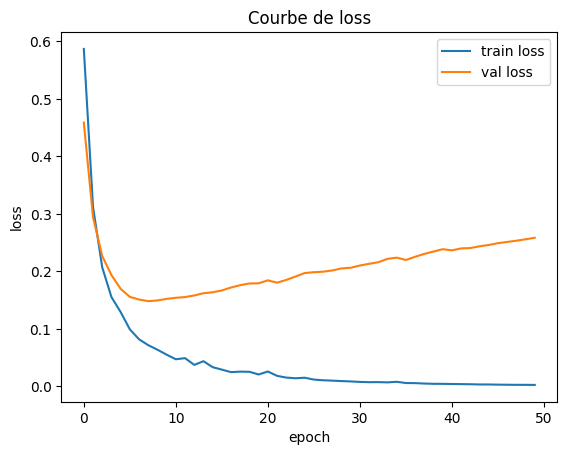

In [ ]:
plt.plot(train_losses, label='train loss')
plt.plot(val_losses,   label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Courbe de loss')
plt.show()

 rechargement du meilleur modèle + évaluation

In [ ]:
best_model = MLP().to(device)
best_model.load_state_dict(torch.load('/content/drive/MyDrive/deep_learning_project/models/mlp_best.params'))
best_model.eval()

with torch.no_grad():
    preds = best_model(X_test).argmax(dim=1).cpu()

y_true = y_test.cpu()

print("accuracy  :", accuracy_score(y_true, preds))
print("precision :", precision_score(y_true, preds))
print("recall    :", recall_score(y_true, preds))
print("f1-score  :", f1_score(y_true, preds))
print("\nmatrice de confusion :")
print(confusion_matrix(y_true, preds))

accuracy  : 0.9736842105263158
precision : 0.9857142857142858
recall    : 0.971830985915493
f1-score  : 0.9787234042553191

matrice de confusion :
[[42  1]
 [ 2 69]]


comparaison des 3 initialisations


In [ ]:
def train_and_eval(init_fn, name):
    m = MLP().to(device)
    m.apply(init_fn)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    for epoch in range(50):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        preds = m(X_test).argmax(dim=1).cpu()
    acc = accuracy_score(y_test.cpu(), preds)
    f1  = f1_score(y_test.cpu(), preds)
    print(f"{name:12} | accuracy: {acc:.4f} | f1: {f1:.4f}")

train_and_eval(init_normal,   "gaussienne")
train_and_eval(init_constant, "constante")
train_and_eval(init_xavier,   "xavier")

gaussienne   | accuracy: 0.9825 | f1: 0.9859
constante    | accuracy: 0.9474 | f1: 0.9577
xavier       | accuracy: 0.9649 | f1: 0.9718


## Question de synthèse – Partie I

Le MLP constitue une solution pertinente pour la classification tabulaire sur le
Breast Cancer Wisconsin dataset. Avec 30 features numériques continues et 569
observations, le dataset est bien adapté à ce type d'architecture : les données
n'ont pas de structure spatiale ni temporelle, ce qui rend le MLP suffisant.

Les résultats obtenus (accuracy ~96-98%, F1 ~97%) confirment cette pertinence.
L'initialisation gaussienne donne les meilleurs résultats sur ce dataset, suivie
de Xavier. L'initialisation constante est clairement inférieure en raison du
problème de symétrie : tous les neurones apprennent la même chose.

Les principales limites du MLP sur des données tabulaires sont :
- Il ne capture pas les relations non-linéaires complexes entre features aussi
  bien qu'un modèle arborescent (Random Forest, XGBoost)
- Il est sensible au choix des hyperparamètres (nb de couches, neurones, lr)
- Sur de petits datasets comme celui-ci, le risque de surapprentissage existe

En conclusion, le MLP est suffisant pour ce problème de classification binaire
simple, mais des modèles comme XGBoost seraient probablement plus robustes sur
des datasets tabulaires plus complexes.